In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm

# Анализ детерминированной задачи

Определим вспомогательные функции.

In [2]:
from stochastique.core.numerical import find_jacobian, find_equilibrium, classify_equilibrium

Определим класс двумерной динамической системы с возможностью нахождения решения методом Рунге-Кутты 4 порядка с суммарной ошибкой $O(h^4)$ на интервале решения, с возможностью построения бифуркационной диаграммы и фазового портрета системы, нахождения равновесий и предельных циклов.

In [3]:
from stochastique.core.dynamic_system import DynamicSystem2D

# 1. Нейронная модель ФитцХью-Нагумо (FHN)

$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) \\
    \dot{y} = x + a
\end{cases}
$$

1. Найдем равновесия системы.

$$
\begin{cases}
    \frac{1}{\delta} (x - \frac{x^3}{3} - y) = 0 \\
    x + a = 0
\end{cases} \implies
\begin{cases}
    \overline{x} = -a \\
    \overline{y} = \frac{a^3}{3} - a
\end{cases}
$$

2. Исследуем равновесия на устойчивость.

$$
J(x, y) = \begin{pmatrix}
\frac{1}{\delta} (1 - x^2) & \frac{1}{\delta} \\
1 & 0
\end{pmatrix}
$$

$$
|J(x, y) - \lambda E| = 0
$$

$$
\lambda_{1,2}(x, y) = \frac{-\delta x^2 + \delta \pm \delta \sqrt{x^4 - 2 x^2 - 4 \delta + 1}}{2 \delta^2}
$$

Далее с помощью численной процедуры исследуем поведение собственных чисел якобиана в равновесных точках при различных значениях параметра $a$.

In [4]:
from stochastique.models.FHN import model_FHN, equilibria_FHN

In [5]:
FHN = DynamicSystem2D(
    model_FHN,
    params=dict(delta=0.1, a=1)
)

3. Построим бифуркационную диаграмму по параметру $a$.

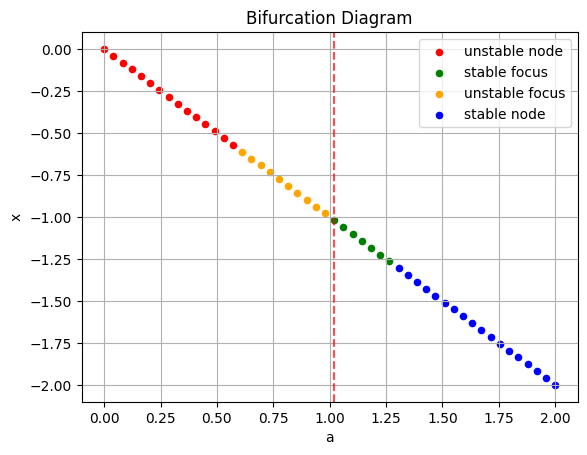

In [6]:
param_name = 'a'
param_values = np.linspace(0, 2, num=50)
state_init = lambda a, delta: np.array([0, 0])

fig, ax = plt.subplots()

bifurcation_points, equilibria = FHN.plot_bifurcation_diagram(
    param_name=param_name,
    param_values=param_values,
    state_init=state_init,
    ax=ax
)

a_bif = bifurcation_points[0]

4. Построим типичные фазовые портреты для различных значений $a$ по бифуркационной диаграмме.

In [7]:
# time_span = np.linspace(0, 50, num=2000)

# a_min = param_values[0]
# a_max = param_values[-1]
# a_values_to_types = [
#     (0.25, "unstable node"),
#     (0.75, "unstable focus"),
#     (1.2, "stable focus"),
#     (1.5, "stable node")
# ]
# a_values, equilibrium_types = zip(*a_values_to_types)

# equilibria_per_value = np.concatenate((param_values[:, None], equilibria), axis=1)
# tolerance = abs(param_values[1] - param_values[0]) / 2

# fig, axes = plt.subplots(1, len(a_values_to_types), figsize=(18, 4))

# for ax, a, eq_type in zip(axes, a_values, equilibrium_types):
#     FHN.params['a'] = a
#     FHN.plot_phase_portrait_dense(
#         ax=ax,
#         equilibria=[np.array([0, 0])],
#         time_span=time_span,
#         bounds=(-2, 2),
#         grid_size=10
#     )

#     equilibrium_idx = np.isclose(equilibria_per_value[:, 0], a, atol=tolerance)
#     equilibrium_value = equilibria_per_value[equilibrium_idx][0]
#     equilibrium_point = equilibrium_value[1:]

#     ax.scatter(*equilibrium_point, color='red', marker='o', s=50, zorder=100, label='equilibria')
#     ax.set_title(f"{a=:.2f}, {eq_type}")
#     ax.legend(loc="lower left")

In [8]:
eqs = equilibria_FHN(a=0.25, delta=0.1)
cycles = FHN.find_all_limit_cycles(equilibria=eqs, bounds=(-4, 4))

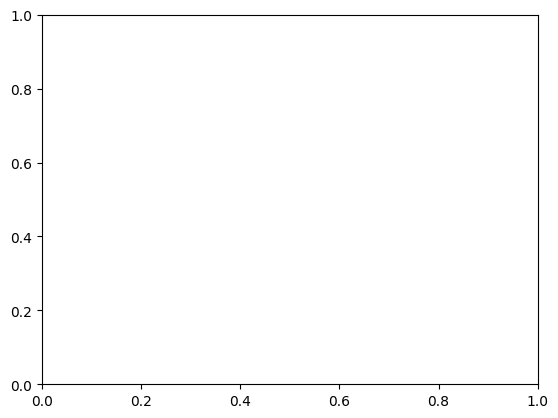

In [9]:
fig, ax = plt.subplots()

FHN.plot_limit_cycles(ax=ax, cycles=cycles)

**Итог**. Нейронная модель ФитцХью-Нагумо имеет одну точку бифуркации $a = 1$. При анализе системы была рассмотрена и визуализирована ее единственная равновесная точка. При изменении параметра $a$, равновесная точка меняет тип 3 раза, а также после бифуркации в точке $a = 1$ предельный цикл исчезает.

# 2. Климатическая модель Зальцман-Николис (SN)

$$
\begin{cases}
    \dot{x} = y - x \\
    \dot{y} = -a x + b y - x^2 y
\end{cases}
$$

1. Найдем равновесия системы.

$$
\begin{cases}
    y - x = 0 \\
    -a x + b y - x^2 y = 0
\end{cases}

\implies

\begin{cases}
    x = y \\
    x(x^2 + a - b) = 0
\end{cases}

\implies

\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

2. Исследуем равновесия на устойчивость.

$$
J(x, y) = \begin{pmatrix}
-1 & 1 \\
-a - 2xy & b - x^2
\end{pmatrix}
$$

$$
|J(x, y) - \lambda E| = 0
$$

$$
\lambda_{1,2}(x, y) = \frac{\pm \sqrt{-4a + b^2 - 2b x^2 + 2b + x^4 - 2x^2 - 8xy + 1} + b - x^2 - 1}{2}
$$

Далее с помощью численной процедуры исследуем поведение собственных чисел якобиана в равновесных точках при различных значениях параметра $a$.

In [9]:
from stochastique.models.SN import model_SN, equilibria_SN

In [10]:
SN = DynamicSystem2D(
    model_SN,
    params=dict(a=1, b=2)
)

3. Построим бифуркационную диаграмму по параметру $a$ для трех равновесий системы:

$$
\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

/tmp/ipykernel_17728/3874313666.py:7: RuntimeWarning: invalid value encountered in sqrt
  lambda a, b: np.array([np.sqrt(b - a), np.sqrt(b - a)]),
/mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/core/bifurcation.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_17728/3874313666.py:8: RuntimeWarning: invalid value encountered in sqrt
  lambda a, b: -np.array([np.sqrt(b - a), np.sqrt(b - a)]),


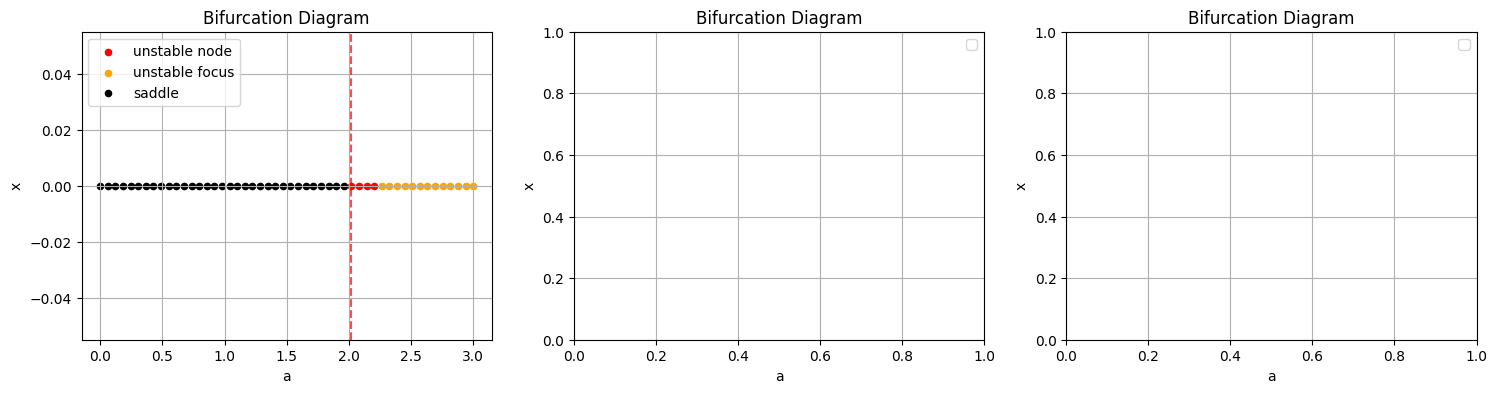

In [11]:
param_name = 'a'
param_values = np.linspace(0, 3, num=50)

b = 2
states_init = [
    lambda a, b: np.array([0., 0.]),
    lambda a, b: np.array([np.sqrt(b - a), np.sqrt(b - a)]),
    lambda a, b: -np.array([np.sqrt(b - a), np.sqrt(b - a)]),
]
equilibria_per_state = []
bif_points_per_state = []

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, state_init in zip(axes, states_init):
    bifurcation_points, equilibria = SN.plot_bifurcation_diagram(
        param_name=param_name,
        param_values=param_values,
        state_init=state_init,
        ax=ax
    )

#     a_bif = bifurcation_points[0]
#     equilibria_per_state.append(equilibria)
#     bif_points_per_state.append(a_bif)

# equilibria = equilibria_per_state[0]
# a_bif = bif_points_per_state[0]

4. Построим типичные фазовые портреты для различных значений $a$ по бифуркационной диаграмме равновесия $(\overline{x}_1, \overline{y}_1) = (0, 0)$.

In [12]:
# time_span = np.linspace(0, 200, num=2000)

# a_min = param_values[0]
# a_max = param_values[-1]
# a_values_to_types = [
#     (0.9, "stable focus"),
#     (1.5, "unstable focus"),
#     (2.0, "unstable node")
# ]
# a_values, equilibrium_types = zip(*a_values_to_types)

# equilibria_per_value = np.concatenate((param_values[:, None], equilibria), axis=1)
# tolerance = abs(param_values[1] - param_values[0]) / 2

# fig, axes = plt.subplots(1, len(a_values_to_types), figsize=(18, 4))

# for ax, a, eq_type in zip(axes, a_values, equilibrium_types):
#     SN.params['a'] = a
#     SN.plot_phase_portrait_dense(
#         ax=ax,
#         equilibria=[
#             np.array([0, 0]),
#             np.array([np.sqrt(b - a), np.sqrt(b - a)]),
#             np.array([-np.sqrt(b - a), -np.sqrt(b - a)])
#         ],
#         time_span=time_span,
#         bounds=(-3, 3),
#         grid_size=10,
#     )

#     equilibrium_idx = np.isclose(equilibria_per_value[:, 0], a, atol=tolerance)
#     equilibrium_value = equilibria_per_value[equilibrium_idx][0]
#     equilibrium_point = equilibrium_value[1:]

#     ax.scatter(*equilibrium_point, color='red', marker='o', s=50, zorder=100, label='equilibria')
#     ax.set_title(f"{a=:.1f}, {eq_type}")
#     ax.legend(loc="upper left")

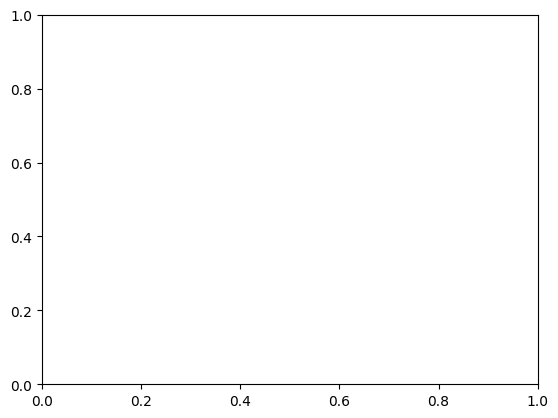

In [13]:
ds = DynamicSystem2D(model_SN, params={'a': 0.6, 'b': 2.0})

eqs = equilibria_SN(a=0.6, b=2.0)

fig, ax = plt.subplots()
cycles = ds.find_all_limit_cycles(equilibria=eqs, bounds=(-4, 4))
ds.plot_limit_cycles(ax, cycles=cycles)

**Итог**. Климатическая модель Зальцман-Николис имеет одну точку бифуркации $a = 2$ для равновесия $(\overline{x}_1, \overline{y}_1) = (0, 0)$. При анализе системы была рассмотрена и визуализирована одна действительная равновесная точка из трех существующих. При изменении параметра $a$, равновесная точка меняет тип 2 раза, а также меняется количество и форма предельных цклов.

# TODO
- Рассмотреть все равновесия (в т.ч. устойчивые при a <= 2) для системы SN, изобразить их и предельные циклы вокруг них на фазовых портретах
- Оформить в LaTeX